**M3 - Modelagem, Avaliação e Análise de Erros - Gustavo Lobato Campos e Rafael Vinicius Tayette da Nobrega**

**Fonte dos dados:** [Kaggle - Solar Power Generation Data (anikannal)](https://www.kaggle.com/datasets/anikannal/solar-power-generation-data)

Este notebook parte da base combinada das Plantas 1 e 2 e implementa a etapa de modelagem preditiva.

Estrutura do notebook:
0. Preparação: base consolidada, engenharia de atributos e split temporal
1. Baseline (piso de desempenho)
2. Experimentos (>= 3 abordagens, CV temporal, média ± desvio)
3. Modelo final (escolha, hiperparâmetros, avaliação no teste)
4. Análise de erros
5. Limitações

---
**A. Configuração inicial:** 

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.dummy import DummyRegressor, DummyClassifier
from sklearn.linear_model import Ridge, LogisticRegression
from sklearn.ensemble import (RandomForestRegressor, RandomForestClassifier,
                              HistGradientBoostingRegressor, HistGradientBoostingClassifier)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit, cross_validate, RandomizedSearchCV
from sklearn.inspection import permutation_importance
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score,
                             classification_report, confusion_matrix, ConfusionMatrixDisplay,
                             roc_auc_score, RocCurveDisplay, f1_score)

sns.set_theme(style='whitegrid', palette='viridis')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.titleweight'] = 'bold'
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 140)

RANDOM_STATE = 42
TARGET       = 'AC_POWER'          # variável de origem (kW)
ALVO         = 'AC_POWER_H1'       # alvo deslocado: AC_POWER 1h à frente
PASSO_MIN    = 15                  # granularidade da série (minutos)
HORIZONTE_H  = 1                   # horizonte de previsão (horas)
DATA_CORTE   = pd.Timestamp('2020-06-10')   # fronteira treino/teste (split temporal)
LIMIAR_BAIXA = 0.50                # evento de baixa geração: < 50% da mediana do horário
N_SPLITS     = 5

def rmse(y, yhat):
    return float(np.sqrt(mean_squared_error(y, yhat)))


In [2]:
# Carregamento e merge das duas plantas (idêntico ao Módulo 2)
gen1 = pd.read_csv('dataset/Plant_1_Generation_Data.csv')
wth1 = pd.read_csv('dataset/Plant_1_Weather_Sensor_Data.csv')
gen2 = pd.read_csv('dataset/Plant_2_Generation_Data.csv')
wth2 = pd.read_csv('dataset/Plant_2_Weather_Sensor_Data.csv')

gen1['DATE_TIME'] = pd.to_datetime(gen1['DATE_TIME'], format='%d-%m-%Y %H:%M')
wth1['DATE_TIME'] = pd.to_datetime(wth1['DATE_TIME'], format='%Y-%m-%d %H:%M:%S')
gen2['DATE_TIME'] = pd.to_datetime(gen2['DATE_TIME'], format='%Y-%m-%d %H:%M:%S')
wth2['DATE_TIME'] = pd.to_datetime(wth2['DATE_TIME'], format='%Y-%m-%d %H:%M:%S')

COLS_CLIMA = ['AMBIENT_TEMPERATURE', 'MODULE_TEMPERATURE', 'IRRADIATION']

def combinar(gen, wth, planta):
    d = pd.merge(gen, wth.drop(columns=['SOURCE_KEY']), on=['DATE_TIME', 'PLANT_ID'], how='left')
    d = d.sort_values('DATE_TIME')
    d[COLS_CLIMA] = d[COLS_CLIMA].interpolate(method='linear', limit_direction='both')
    d['PLANTA'] = planta
    return d

df = pd.concat([combinar(gen1, wth1, 1), combinar(gen2, wth2, 2)], ignore_index=True)
df = df.sort_values(['PLANTA', 'SOURCE_KEY', 'DATE_TIME']).reset_index(drop=True)

print(f"Base consolidada: {df.shape[0]:,} registros x {df.shape[1]} colunas".replace(',', '.'))
print(f"\nPeríodo: {df['DATE_TIME'].min()} a {df['DATE_TIME'].max()}\n")
print(df.groupby('PLANTA').agg(registros=('AC_POWER', 'size'),
                               inversores=('SOURCE_KEY', 'nunique'),
                               ac_max=('AC_POWER', 'max'),
                               dc_max=('DC_POWER', 'max')))


Base consolidada: 136.476 registros x 11 colunas

Período: 2020-05-15 00:00:00 a 2020-06-17 23:45:00

        registros  inversores   ac_max        dc_max
PLANTA                                              
1           68778          22  1410.95  14471.125000
2           67698          22  1385.42   1420.933333


---

**B Engenharia de atributos:**

Três decisões impactam a matriz de atributos, porque determinam a validade de tudo que vem na sequência.

(a) Vazamento temporal. `AC_POWER` e `DC_POWER` no mesmo instante têm correlação próxima de 1 (Módulo 2, seção 4.4). Um modelo que prevê `AC_POWER(t)` a partir de `DC_POWER(t)` atinge R² ≈ 0,999 e não prevê nada: apenas reaprende a eficiência de conversão do inversor. Por isso o alvo é deslocado para **t + 1h** e todos os atributos são medidos em **t**, ou seja, em um instante anterior. Assim, `DC_POWER(t)` passa a ser um atributo legítimo.

(b) Deslocamentos por junção, não por `shift()`. A série tem lacunas (timestamps ausentes). `groupby().shift(4)` deslocaria 4 *linhas*, não 4 *passos de 15 min*, corrompendo silenciosamente os lags (atraso ou descolamento) nas bordas das lacunas. Os deslocamentos são feitos por `merge` sobre `DATE_TIME + Δ`, o que é exato na presença de lacunas.

(c) Escala de `DC_POWER` entre plantas. Na Planta 1 `DC_POWER` é reportada uma escala cerca de 10x maior que na Planta 2 (ver `dc_max` acima), consequência de arranjos distintos de string/inversor. Usar a variável bruta com as duas plantas juntas cria um atributo cujo significado muda conforme a planta. Assim, é incluída a versão normalizada pelo máximo de treino da própria planta.

`DAILY_YIELD` e `TOTAL_YIELD` são descartados: são acumuladores monotônicos que codificam a posição no dia e no período de coleta, gerando um atalho que não sobrevive fora da janela de 34 dias.

In [3]:
CHAVE = ['PLANTA', 'SOURCE_KEY']

def deslocar(base, colunas, passos, sufixo):
    """Desloca `colunas` em `passos` * 15 min via merge exato sobre DATE_TIME.
    passos > 0 -> valor passado (lag). passos < 0 -> valor futuro (alvo)."""
    delta = pd.Timedelta(minutes=PASSO_MIN * passos)
    aux = base[CHAVE + ['DATE_TIME'] + colunas].copy()
    aux['DATE_TIME'] = aux['DATE_TIME'] + delta
    aux = aux.rename(columns={c: f'{c}{sufixo}' for c in colunas})
    return base.merge(aux, on=CHAVE + ['DATE_TIME'], how='left')

# --- alvo: AC_POWER 1h à frente (4 passos de 15 min) ---
df = deslocar(df, [TARGET], -4, '_H1')

# --- lags de potência (15, 30, 60 min atrás) ---
for p in [1, 2, 4]:
    df = deslocar(df, ['AC_POWER', 'DC_POWER'], p, f'_lag{p}')

# --- lag de clima (60 min atrás), para capturar tendência ---
df = deslocar(df, COLS_CLIMA, 4, '_lag4')

# --- variações (rampas): sinal de nebulosidade em movimento ---
df['D_IRRADIATION_1H']  = df['IRRADIATION'] - df['IRRADIATION_lag4']
df['D_AC_POWER_1H']     = df['AC_POWER'] - df['AC_POWER_lag4']
df['D_MODULE_TEMP_1H']  = df['MODULE_TEMPERATURE'] - df['MODULE_TEMPERATURE_lag4']
df['DELTA_TEMP']        = df['MODULE_TEMPERATURE'] - df['AMBIENT_TEMPERATURE']

# --- janelas móveis de 1h sobre AC_POWER (nível e volatilidade recentes) ---
df = df.sort_values(CHAVE + ['DATE_TIME'])
roll = df.set_index('DATE_TIME').groupby(CHAVE)['AC_POWER'].rolling('1h')
df['AC_MEDIA_1H'] = roll.mean().reset_index(level=[0, 1], drop=True).values
df['AC_DESVIO_1H'] = roll.std().reset_index(level=[0, 1], drop=True).fillna(0).values

# --- atributos temporais: minuto do dia em codificação cíclica ---
df['MINUTO_DIA'] = df['DATE_TIME'].dt.hour * 60 + df['DATE_TIME'].dt.minute
df['HORA']       = df['DATE_TIME'].dt.hour
df['SIN_DIA']    = np.sin(2 * np.pi * df['MINUTO_DIA'] / 1440)
df['COS_DIA']    = np.cos(2 * np.pi * df['MINUTO_DIA'] / 1440)
df['DIA_PERIODO'] = (df['DATE_TIME'] - df['DATE_TIME'].min()).dt.days

# --- remoção de bordas: qualquer NaN em coluna efetivamente usada torna a linha inválida ---
# Os lags/rampas são feitos por merge sobre DATE_TIME (correto na presença de lacunas), o que
# gera NaN sempre que o vizinho de 15/30/60 min não existe. Como o Ridge (E1) e a regressão
# logística (C1) não aceitam NaN nativamente, as linhas incompletas são removidas AQUI, uma vez,
# garantindo que as duas trilhas (A e B) treinem exatamente sobre a mesma base limpa.
COLS_MODELAGEM = [
    'AC_POWER', 'AC_POWER_lag1', 'AC_POWER_lag2', 'AC_POWER_lag4',
    'DC_POWER', 'DC_POWER_lag1', 'DC_POWER_lag2', 'DC_POWER_lag4',
    'IRRADIATION', 'IRRADIATION_lag4',
    'AMBIENT_TEMPERATURE', 'AMBIENT_TEMPERATURE_lag4',
    'MODULE_TEMPERATURE', 'MODULE_TEMPERATURE_lag4',
    'D_IRRADIATION_1H', 'D_AC_POWER_1H', 'D_MODULE_TEMP_1H', 'DELTA_TEMP',
    'AC_MEDIA_1H', 'AC_DESVIO_1H', 'SIN_DIA', 'COS_DIA', 'MINUTO_DIA',
    ALVO,
]

n_antes = len(df)
na_por_coluna = df[COLS_MODELAGEM].isna().sum()
na_por_coluna = na_por_coluna[na_por_coluna > 0].sort_values(ascending=False)

df = df.dropna(subset=COLS_MODELAGEM).reset_index(drop=True)

print(f"Linhas antes de remover bordas: {n_antes:,}".replace(',', '.'))
print(f"Linhas após remover bordas (lags/rampas/alvo indefinidos): {len(df):,}".replace(',', '.'))
print(f"Removidas: {n_antes - len(df):,} ({(n_antes - len(df)) / n_antes:.2%} da base)".replace(',', '.'))
if len(na_por_coluna):
    print("\nAusentes por coluna que motivaram a remoção (antes do dropna):")
    for col, q in na_por_coluna.items():
        print(f"   {col:28s}: {int(q):>6,}".replace(',', '.'))

# Verificação explícita: nenhuma coluna de modelagem deve conter NaN a partir daqui
assert df[COLS_MODELAGEM].isna().sum().sum() == 0, "Ainda há NaN em colunas de modelagem"
print("\nVerificação: 0 NaN nas colunas de modelagem. Base pronta para treino.")


Linhas antes de remover bordas: 136.476
Linhas após remover bordas (lags/rampas/alvo indefinidos): 133.253
Removidas: 3.223 (2.36% da base)

Ausentes por coluna que motivaram a remoção (antes do dropna):
   AC_POWER_lag4               :  1.405
   MODULE_TEMPERATURE_lag4     :  1.405
   AMBIENT_TEMPERATURE_lag4    :  1.405
   IRRADIATION_lag4            :  1.405
   DC_POWER_lag4               :  1.405
   D_IRRADIATION_1H            :  1.405
   D_AC_POWER_1H               :  1.405
   D_MODULE_TEMP_1H            :  1.405
   AC_POWER_H1                 :  1.405
   AC_POWER_lag2               :    837
   DC_POWER_lag2               :    837
   DC_POWER_lag1               :    496
   AC_POWER_lag1               :    496

Verificação: 0 NaN nas colunas de modelagem. Base pronta para treino.


---
**C Split temporal e definição do evento operacional:**

O split é temporal, não aleatório: treino até 09/06/2020, teste de 10/06 a 17/06/2020. Um `train_test_split` aleatório colocaria vizinhos de 15 minutos em partições opostas, e a autocorrelação da série produziria uma métrica de teste otimista e sem sentido.

O evento `EVENTO_BAIXA` compara o alvo com a mediana histórica do mesmo horário e da mesma planta, calculada apenas no treino, nenhuma estatística do teste entra na definição do rótulo. Horários cuja mediana de treino é zero (noite) são excluídos da Trilha B: prever "não haverá geração às 2h da manhã" não é considerada uma tarefa.

In [4]:
treino_mask = df['DATE_TIME'] < DATA_CORTE
teste_mask  = ~treino_mask

# Normalização de DC_POWER pelo máximo de treino da própria planta (ver decisão (c))
dc_max_treino = df[treino_mask].groupby('PLANTA')['DC_POWER'].max()
for col in ['DC_POWER', 'DC_POWER_lag1', 'DC_POWER_lag2', 'DC_POWER_lag4']:
    df[f'{col}_NORM'] = df[col] / df['PLANTA'].map(dc_max_treino)

# Mediana de referência por (planta, minuto do dia), estimada SÓ no treino
ref = (df[treino_mask].groupby(['PLANTA', 'MINUTO_DIA'])[TARGET]
       .median().rename('MEDIANA_SLOT').reset_index())
df = df.merge(ref, on=['PLANTA', 'MINUTO_DIA'], how='left')
df['MEDIANA_SLOT'] = df['MEDIANA_SLOT'].fillna(0)

# Trilha B: rótulo binário e máscara de período diurno
df['DIURNO'] = df['MEDIANA_SLOT'] > 0
df['EVENTO_BAIXA'] = ((df[ALVO] < LIMIAR_BAIXA * df['MEDIANA_SLOT']) & df['DIURNO']).astype(int)

ATRIBUTOS = [
    'AC_POWER', 'AC_POWER_lag1', 'AC_POWER_lag2', 'AC_POWER_lag4',
    'DC_POWER_NORM', 'DC_POWER_lag1_NORM', 'DC_POWER_lag2_NORM', 'DC_POWER_lag4_NORM',
    'IRRADIATION', 'IRRADIATION_lag4',
    'AMBIENT_TEMPERATURE', 'AMBIENT_TEMPERATURE_lag4',
    'MODULE_TEMPERATURE', 'MODULE_TEMPERATURE_lag4',
    'D_IRRADIATION_1H', 'D_AC_POWER_1H', 'D_MODULE_TEMP_1H', 'DELTA_TEMP',
    'AC_MEDIA_1H', 'AC_DESVIO_1H',
    'SIN_DIA', 'COS_DIA', 'MINUTO_DIA', 'PLANTA', 'MEDIANA_SLOT',
]

# Ordenação cronológica global: pré-requisito do TimeSeriesSplit
treino = df[treino_mask].sort_values('DATE_TIME').reset_index(drop=True)
teste  = df[teste_mask].sort_values('DATE_TIME').reset_index(drop=True)

X_tr, y_tr = treino[ATRIBUTOS], treino[ALVO]
X_te, y_te = teste[ATRIBUTOS],  teste[ALVO]

# Trilha B: apenas linhas diurnas
tr_d, te_d = treino[treino['DIURNO']], teste[teste['DIURNO']]
Xc_tr, yc_tr = tr_d[ATRIBUTOS], tr_d['EVENTO_BAIXA']
Xc_te, yc_te = te_d[ATRIBUTOS], te_d['EVENTO_BAIXA']

print(f"Treino: {len(treino):,} linhas  ({treino['DATE_TIME'].min().date()} a {treino['DATE_TIME'].max().date()})".replace(',', '.'))
print(f"Teste : {len(teste):,} linhas  ({teste['DATE_TIME'].min().date()} a {teste['DATE_TIME'].max().date()})".replace(',', '.'))
print(f"Atributos: {len(ATRIBUTOS)}\n")
print("Trilha B - prevalência do evento de baixa geração (linhas diurnas):")
print(f"  treino: {yc_tr.mean():.2%}  ({yc_tr.sum():,} positivos de {len(yc_tr):,})".replace(',', '.'))
print(f"  teste : {yc_te.mean():.2%}  ({yc_te.sum():,} positivos de {len(yc_te):,})".replace(',', '.'))


Treino: 99.813 linhas  (2020-05-15 a 2020-06-09)
Teste : 33.440 linhas  (2020-06-10 a 2020-06-17)
Atributos: 25

Trilha B - prevalência do evento de baixa geração (linhas diurnas):
  treino: 30.92%  (16.627 positivos de 53.776)
  teste : 36.47%  (6.499 positivos de 17.820)


---
**1. Baseline:**

O baseline define o piso, uma vez que o desempenho que qualquer modelo precisa superar este para justificar sua existência. Ou seja, não adianta ter um modelo complexo que não bate o baseline, logo ele será descartado.

**Trilha A (dois baselines):**

- Persistência (`ŷ(t+1h) = AC_POWER(t)`): o baseline canônico de séries temporais. É a hipótese "nada muda em uma hora". Difícil de bater em horizontes curtos e trivial de implementar — é o piso honesto.
- Climatologia por horário (`ŷ(t+1h) = mediana de treino do slot`): ignora o estado atual e usa apenas a curva média do dia. É o piso do "modelo que só sabe que horas são".

A comparação entre os dois já é informativa: se a persistência vence, a informação está no estado recente; se a climatologia vence, está no ciclo diurno.

**Trilha B (dois baselines):**
- Classe majoritária (`DummyClassifier`): nunca prevê evento. Acurácia alta, recall zero. Serve para expor porque acurácia não é uma métrica adaequada para este caso.
- Persistência do evento: prevê evento em `t+1h` se a geração em `t` já está abaixo do limiar. 

**Piso diurno vs. base completa.** `AC_POWER` é zero em cerca de metade das linhas (período noturno), e todo baseline acerta esses zeros trivialmente. O RMSE calculado sobre a base inteira é, portanto, diluído por essas linhas fáceis e superestima a qualidade do piso. Por isso o piso é reportado também restrito ao período diurno, sendo uma régua honesta, onde persistência e climatologia efetivamente competem e onde o ganho do modelo final precisa aparecer.

In [5]:
# --- Trilha A: baselines de regressão ---
base_persistencia_te  = teste['AC_POWER'].values
base_climatologia_te  = teste['MEDIANA_SLOT'].values
base_persistencia_tr  = treino['AC_POWER'].values
base_climatologia_tr  = treino['MEDIANA_SLOT'].values

linhas = []
for nome, p_tr, p_te in [('Persistência: ŷ(t+1h) = AC_POWER(t)', base_persistencia_tr, base_persistencia_te),
                         ('Climatologia: mediana do horário (treino)', base_climatologia_tr, base_climatologia_te)]:
    linhas.append({'baseline': nome,
                   'RMSE_treino': rmse(y_tr, p_tr), 'MAE_treino': mean_absolute_error(y_tr, p_tr),
                   'RMSE_teste': rmse(y_te, p_te),  'MAE_teste': mean_absolute_error(y_te, p_te),
                   'R2_teste': r2_score(y_te, p_te)})

baseline_reg = pd.DataFrame(linhas).round(3)
PISO_RMSE = baseline_reg['RMSE_teste'].min()
print(f"AC_POWER no teste: média = {y_te.mean():.1f} kW | desvio = {y_te.std():.1f} kW | máx = {y_te.max():.1f} kW\n")
display(baseline_reg)
print(f"\n>>> PISO (Trilha A - base completa): RMSE de teste a superar = {PISO_RMSE:.3f} kW")

# --- Decomposição do piso por período: diurno vs. noturno ---
# AC_POWER = 0 em ~metade das linhas (noite). Todo baseline acerta esses zeros trivialmente,
# então o RMSE da base completa é diluído pelas linhas fáceis. O piso relevante é o diurno.
mask_diurno_te = teste['DIURNO'].values
piso_por_periodo = []
for nome, p_te in [('Persistência', base_persistencia_te),
                   ('Climatologia', base_climatologia_te)]:
    for periodo, m in [('Diurno', mask_diurno_te), ('Noturno', ~mask_diurno_te), ('Completo', np.ones(len(y_te), bool))]:
        if m.sum() == 0:
            continue
        piso_por_periodo.append({
            'baseline': nome, 'período': periodo, 'n_linhas': int(m.sum()),
            'RMSE': rmse(y_te.values[m], p_te[m]),
            'MAE':  mean_absolute_error(y_te.values[m], p_te[m])})

piso_periodo = pd.DataFrame(piso_por_periodo)
PISO_RMSE_DIURNO = piso_periodo.query("período == 'Diurno'")['RMSE'].min()
pct_noturno = float((~mask_diurno_te).mean() * 100)

print(f"\nComposição do teste: {pct_noturno:.1f}% das linhas são noturnas (AC_POWER = 0, acerto trivial).")
display(piso_periodo.round(3).pivot_table(index='baseline', columns='período',
        values=['RMSE', 'MAE'], observed=True))
print(f">>> PISO relevante (Trilha A - período DIURNO): RMSE a superar = {PISO_RMSE_DIURNO:.3f} kW")
print("    O piso diurno é a régua honesta: é onde persistência e climatologia realmente competem,")
print("    e onde o modelo final precisa demonstrar ganho. Decomposição completa na Seção 4.")


AC_POWER no teste: média = 235.0 kW | desvio = 326.2 kW | máx = 1411.0 kW



,baseline,RMSE_treino,MAE_treino,RMSE_teste,MAE_teste,R2_teste
0,Persistência: ŷ(t+1h) = AC_POWER(t),220.124,124.619,189.643,108.218,0.662
1,Climatologia: mediana do horário (treino),242.345,141.863,233.127,137.183,0.489



>>> PISO (Trilha A - base completa): RMSE de teste a superar = 189.643 kW

Composição do teste: 46.7% das linhas são noturnas (AC_POWER = 0, acerto trivial).


MAE                      RMSE                 
período      Completo   Diurno Noturno Completo   Diurno Noturno
baseline                                                        
Climatologia  137.183  253.827   4.110  233.127  318.893  18.305
Persistência  108.218  199.457   4.128  189.643  259.221  18.308

>>> PISO relevante (Trilha A - período DIURNO): RMSE a superar = 259.221 kW
    O piso diurno é a régua honesta: é onde persistência e climatologia realmente competem,
    e onde o modelo final precisa demonstrar ganho. Decomposição completa na Seção 4.


In [6]:
# --- Trilha B: baselines de classificação ---
dummy = DummyClassifier(strategy='most_frequent').fit(Xc_tr, yc_tr)
pred_dummy = dummy.predict(Xc_te)

# persistência do evento: já está baixo agora -> estará baixo em 1h
pred_persist = ((te_d['AC_POWER'] < LIMIAR_BAIXA * te_d['MEDIANA_SLOT'])).astype(int).values

linhas = []
for nome, pred, score in [('Classe majoritária (nunca prevê evento)', pred_dummy, dummy.predict_proba(Xc_te)[:, 1]),
                          ('Persistência do evento', pred_persist, pred_persist.astype(float))]:
    linhas.append({'baseline': nome,
                   'acurácia': (pred == yc_te).mean(),
                   'F1_evento': f1_score(yc_te, pred, zero_division=0),
                   'ROC_AUC': roc_auc_score(yc_te, score)})

baseline_clf = pd.DataFrame(linhas).round(3)
PISO_AUC = baseline_clf['ROC_AUC'].max()
display(baseline_clf)
print(f"\n>>> PISO (Trilha B): ROC-AUC de teste a superar = {PISO_AUC:.3f}")
print("Observação: a classe majoritária atinge acurácia alta com F1 = 0 no evento de interesse.")
print("Acurácia é métrica inadequada sob desbalanceamento; ROC-AUC e F1 do evento são as métricas de decisão.")


,baseline,acurácia,F1_evento,ROC_AUC
0,Classe majoritária (nunca prevê evento),0.635,0.00,0.500
1,Persistência do evento,0.627,0.33,0.547



>>> PISO (Trilha B): ROC-AUC de teste a superar = 0.547
Observação: a classe majoritária atinge acurácia alta com F1 = 0 no evento de interesse.
Acurácia é métrica inadequada sob desbalanceamento; ROC-AUC e F1 do evento são as métricas de decisão.


---
**2. Experimentos:**

Protocolo de validação: `TimeSeriesSplit(n_splits=5)` sobre o conjunto de treino ordenado cronologicamente. Cada fold treina no passado e valida no futuro imediato. `KFold` embaralhado é inválido aqui, pois validaria o modelo em instantes anteriores aos que ele viu no treino, medindo interpolação em vez de previsão.

Métrica primária: RMSE (Trilha A). Penaliza quadraticamente os erros grandes, que na operação da usina são exatamente os que importam: pois, um erro de 400 kW ao meio-dia "custa mais" que 40 erros de 10 kW ao amanhecer. Métrica secundária: MAE, interpretável na unidade física (kW médios de desvio).

Cada execução é reportada como **média ± desvio-padrão entre os 5 folds**. O desvio importa tanto quanto a média: um modelo com RMSE 40 ± 3 é operacionalmente preferível a um com RMSE 38 ± 15, porque o segundo tem semanas em que falha.

In [7]:
cv = TimeSeriesSplit(n_splits=N_SPLITS)
SCORING_REG = {'rmse': 'neg_root_mean_squared_error', 'mae': 'neg_mean_absolute_error'}

experimentos_reg = {
    'E1 - Ridge (linear regularizado)': Pipeline([
        ('escala', StandardScaler()),
        ('modelo', Ridge(alpha=1.0, random_state=RANDOM_STATE))]),

    'E2 - Random Forest': RandomForestRegressor(
        n_estimators=200, max_depth=16, min_samples_leaf=5,
        n_jobs=-1, random_state=RANDOM_STATE),

    'E3 - HistGradientBoosting': HistGradientBoostingRegressor(
        max_iter=300, learning_rate=0.08, max_depth=None, max_leaf_nodes=31,
        l2_regularization=1.0, early_stopping=False, random_state=RANDOM_STATE),

    'E4 - HGB profundo (mais capacidade)': HistGradientBoostingRegressor(
        max_iter=600, learning_rate=0.05, max_leaf_nodes=63,
        min_samples_leaf=40, l2_regularization=2.0,
        early_stopping=False, random_state=RANDOM_STATE),
}

resultados = []
for nome, modelo in experimentos_reg.items():
    r = cross_validate(modelo, X_tr, y_tr, cv=cv, scoring=SCORING_REG, n_jobs=1)
    resultados.append({
        'experimento': nome,
        'RMSE_médio': -r['test_rmse'].mean(), 'RMSE_std': r['test_rmse'].std(),
        'MAE_médio':  -r['test_mae'].mean(),  'MAE_std':  r['test_mae'].std(),
        'tempo_fit_s': r['fit_time'].mean(),
    })
    print(f"{nome:42s}  RMSE = {-r['test_rmse'].mean():7.3f} ± {r['test_rmse'].std():5.3f}")

cv_reg = pd.DataFrame(resultados).sort_values('RMSE_médio').reset_index(drop=True)
cv_reg.round(3)


E1 - Ridge (linear regularizado)            RMSE = 181.592 ± 5.151
E2 - Random Forest                          RMSE = 171.334 ± 7.261
E3 - HistGradientBoosting                   RMSE = 172.326 ± 7.326
E4 - HGB profundo (mais capacidade)         RMSE = 174.433 ± 5.830


,experimento,RMSE_médio,RMSE_std,MAE_médio,MAE_std,tempo_fit_s
0,E2 - Random Forest,171.334,7.261,86.140,5.774,46.344
1,E3 - HistGradientBoosting,172.326,7.326,86.747,5.188,2.938
2,E4 - HGB profundo (mais capacidade),174.433,5.830,87.745,5.006,8.351
3,E1 - Ridge (linear regularizado),181.592,5.151,117.206,4.169,0.070


In [8]:
# E5 - busca de hiperparâmetros sobre a família vencedora (boosting), com CV temporal
espaco = {
    'max_iter':          [300, 500, 800],
    'learning_rate':     [0.03, 0.05, 0.08, 0.12],
    'max_leaf_nodes':    [31, 63, 127],
    'min_samples_leaf':  [20, 40, 80],
    'l2_regularization': [0.0, 1.0, 5.0],
}
busca = RandomizedSearchCV(
    HistGradientBoostingRegressor(early_stopping=False, random_state=RANDOM_STATE),
    param_distributions=espaco, n_iter=15, cv=cv,
    scoring='neg_root_mean_squared_error', random_state=RANDOM_STATE, n_jobs=-1, refit=True)
busca.fit(X_tr, y_tr)

i = busca.best_index_
rmse_e5, std_e5 = -busca.cv_results_['mean_test_score'][i], busca.cv_results_['std_test_score'][i]
print("E5 - melhores hiperparâmetros:")
for k, v in busca.best_params_.items():
    print(f"   {k:20s} = {v}")
print(f"\nE5 - RMSE CV = {rmse_e5:.3f} ± {std_e5:.3f}")

r_e5 = cross_validate(busca.best_estimator_, X_tr, y_tr, cv=cv, scoring=SCORING_REG, n_jobs=1)
cv_reg = pd.concat([cv_reg, pd.DataFrame([{
    'experimento': 'E5 - HGB ajustado (RandomizedSearchCV)',
    'RMSE_médio': -r_e5['test_rmse'].mean(), 'RMSE_std': r_e5['test_rmse'].std(),
    'MAE_médio':  -r_e5['test_mae'].mean(),  'MAE_std':  r_e5['test_mae'].std(),
    'tempo_fit_s': r_e5['fit_time'].mean()}])], ignore_index=True).sort_values('RMSE_médio').reset_index(drop=True)

cv_reg['RMSE (média ± std)'] = cv_reg.apply(lambda l: f"{l['RMSE_médio']:.3f} ± {l['RMSE_std']:.3f}", axis=1)
cv_reg['MAE (média ± std)']  = cv_reg.apply(lambda l: f"{l['MAE_médio']:.3f} ± {l['MAE_std']:.3f}", axis=1)
cv_reg[['experimento', 'RMSE (média ± std)', 'MAE (média ± std)', 'tempo_fit_s']].round(3)


E5 - melhores hiperparâmetros:
   min_samples_leaf     = 20
   max_leaf_nodes       = 31
   max_iter             = 300
   learning_rate        = 0.03
   l2_regularization    = 1.0

E5 - RMSE CV = 168.851 ± 7.429


,experimento,RMSE (média ± std),MAE (média ± std),tempo_fit_s
0,E5 - HGB ajustado (RandomizedSearchCV),168.851 ± 7.429,85.422 ± 5.518,3.273
1,E2 - Random Forest,171.334 ± 7.261,86.140 ± 5.774,46.344
2,E3 - HistGradientBoosting,172.326 ± 7.326,86.747 ± 5.188,2.938
3,E4 - HGB profundo (mais capacidade),174.433 ± 5.830,87.745 ± 5.006,8.351
4,E1 - Ridge (linear regularizado),181.592 ± 5.151,117.206 ± 4.169,0.070


In [9]:
# --- Trilha B: experimentos de classificação, mesmo CV temporal ---
experimentos_clf = {
    'C1 - Regressão logística': Pipeline([
        ('escala', StandardScaler()),
        ('modelo', LogisticRegression(max_iter=2000, class_weight='balanced',
                                      random_state=RANDOM_STATE))]),
    'C2 - Random Forest': RandomForestClassifier(
        n_estimators=200, max_depth=16, min_samples_leaf=5, class_weight='balanced',
        n_jobs=-1, random_state=RANDOM_STATE),
    'C3 - HistGradientBoosting': HistGradientBoostingClassifier(
        max_iter=300, learning_rate=0.08, max_leaf_nodes=31, l2_regularization=1.0,
        early_stopping=False, random_state=RANDOM_STATE),
}

res_clf = []
for nome, modelo in experimentos_clf.items():
    r = cross_validate(modelo, Xc_tr, yc_tr, cv=cv,
                       scoring={'auc': 'roc_auc', 'f1': 'f1'}, n_jobs=1)
    res_clf.append({'experimento': nome,
                    'ROC_AUC (média ± std)': f"{r['test_auc'].mean():.3f} ± {r['test_auc'].std():.3f}",
                    'F1_evento (média ± std)': f"{r['test_f1'].mean():.3f} ± {r['test_f1'].std():.3f}",
                    'auc_medio': r['test_auc'].mean()})
    print(f"{nome:30s}  AUC = {r['test_auc'].mean():.3f} ± {r['test_auc'].std():.3f}")

cv_clf = pd.DataFrame(res_clf).sort_values('auc_medio', ascending=False).reset_index(drop=True)
cv_clf.drop(columns='auc_medio')


C1 - Regressão logística        AUC = 0.932 ± 0.017
C2 - Random Forest              AUC = 0.939 ± 0.013
C3 - HistGradientBoosting       AUC = 0.930 ± 0.015


,experimento,ROC_AUC (média ± std),F1_evento (média ± std)
0,C2 - Random Forest,0.939 ± 0.013,0.807 ± 0.030
1,C1 - Regressão logística,0.932 ± 0.017,0.792 ± 0.035
2,C3 - HistGradientBoosting,0.930 ± 0.015,0.801 ± 0.033


---
**3. Modelo final:**

A escolha segue três critérios, nesta ordem:
1. RMSE de CV (média entre folds) - desempenho esperado;
2. Desvio-padrão entre folds - estabilidade ao longo do tempo, que é o que sustenta o modelo em produção;
3. Custo de ajuste e simplicidade - critério de desempate quando (1) e (2) são estatisticamente indistinguíveis (diferença menor que 1 desvio-padrão).

O modelo é reajustado sobre o **treino completo** e avaliado **uma única vez** sobre o conjunto de teste, que permaneceu intocado até este ponto.

In [10]:
# Seleção automática pelo critério (1), com verificação explícita do critério (2)
melhor_nome = cv_reg.iloc[0]['experimento']
mapa = dict(experimentos_reg); mapa['E5 - HGB ajustado (RandomizedSearchCV)'] = busca.best_estimator_
modelo_final = mapa[melhor_nome]

margem = cv_reg.iloc[1]['RMSE_médio'] - cv_reg.iloc[0]['RMSE_médio']
print(f"Melhor por RMSE de CV : {melhor_nome}")
print(f"RMSE CV               : {cv_reg.iloc[0]['RMSE_médio']:.3f} ± {cv_reg.iloc[0]['RMSE_std']:.3f}")
print(f"Vantagem sobre o 2º   : {margem:.3f} kW  |  1 desvio-padrão = {cv_reg.iloc[0]['RMSE_std']:.3f} kW")
print(f"Diferença {'É' if margem > cv_reg.iloc[0]['RMSE_std'] else 'NÃO é'} maior que 1 desvio-padrão"
      f" -> escolha {'sustentada pelo desempenho' if margem > cv_reg.iloc[0]['RMSE_std'] else 'deve considerar simplicidade/custo'}.\n")

modelo_final.fit(X_tr, y_tr)
pred_te = modelo_final.predict(X_te)
pred_te = np.clip(pred_te, 0, None)   # restrição física: potência AC não é negativa

met_final = {'RMSE': rmse(y_te, pred_te), 'MAE': mean_absolute_error(y_te, pred_te),
             'R2': r2_score(y_te, pred_te)}
print("=== Trilha A - desempenho no conjunto de TESTE ===")
for k, v in met_final.items():
    print(f"  {k:5s} = {v:.3f}")
print(f"\n  Piso (melhor baseline)   RMSE = {PISO_RMSE:.3f}")
print(f"  Redução sobre o piso            = {(1 - met_final['RMSE'] / PISO_RMSE):.1%}")
print(f"  MAE em % da capacidade máx.     = {met_final['MAE'] / y_te.max():.2%}")


Melhor por RMSE de CV : E5 - HGB ajustado (RandomizedSearchCV)
RMSE CV               : 168.851 ± 7.429
Vantagem sobre o 2º   : 2.484 kW  |  1 desvio-padrão = 7.429 kW
Diferença NÃO é maior que 1 desvio-padrão -> escolha deve considerar simplicidade/custo.

=== Trilha A - desempenho no conjunto de TESTE ===
  RMSE  = 146.796
  MAE   = 73.744
  R2    = 0.797

  Piso (melhor baseline)   RMSE = 189.643
  Redução sobre o piso            = 22.6%
  MAE em % da capacidade máx.     = 5.23%


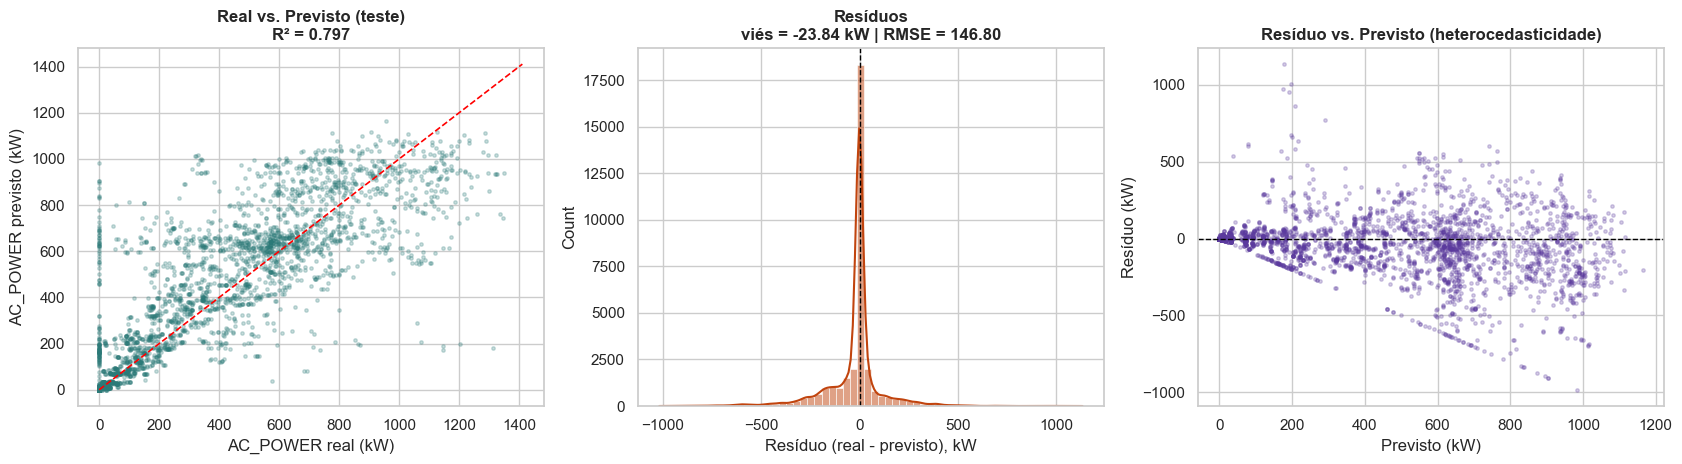

In [11]:
# Diagnóstico visual da regressão no teste
residuo = y_te.values - pred_te
fig, ax = plt.subplots(1, 3, figsize=(17, 4.8))

idx = np.random.default_rng(RANDOM_STATE).choice(len(y_te), min(5000, len(y_te)), replace=False)
ax[0].scatter(y_te.values[idx], pred_te[idx], s=6, alpha=0.25, color='#2b7a78')
lim = [0, max(y_te.max(), pred_te.max())]
ax[0].plot(lim, lim, 'r--', lw=1.2)
ax[0].set_xlabel('AC_POWER real (kW)'); ax[0].set_ylabel('AC_POWER previsto (kW)')
ax[0].set_title(f"Real vs. Previsto (teste)\nR² = {met_final['R2']:.3f}")

sns.histplot(residuo, bins=60, kde=True, ax=ax[1], color='#c1440e')
ax[1].axvline(0, color='k', ls='--', lw=1)
ax[1].set_xlabel('Resíduo (real - previsto), kW')
ax[1].set_title(f"Resíduos\nviés = {residuo.mean():+.2f} kW | RMSE = {met_final['RMSE']:.2f}")

ax[2].scatter(pred_te[idx], residuo[idx], s=6, alpha=0.25, color='#5b3a9e')
ax[2].axhline(0, color='k', ls='--', lw=1)
ax[2].set_xlabel('Previsto (kW)'); ax[2].set_ylabel('Resíduo (kW)')
ax[2].set_title('Resíduo vs. Previsto (heterocedasticidade)')

plt.tight_layout(); plt.show()


In [12]:
# Trilha B: modelo final de classificação, artefatos exigidos no enunciado
melhor_clf_nome = cv_clf.iloc[0]['experimento']
clf_final = experimentos_clf[melhor_clf_nome]
clf_final.fit(Xc_tr, yc_tr)

proba_te = clf_final.predict_proba(Xc_te)[:, 1]
pred_clf = (proba_te >= 0.5).astype(int)
auc = roc_auc_score(yc_te, proba_te)

print(f"Modelo final da Trilha B: {melhor_clf_nome}\n")
print("=== classification_report (conjunto de teste) ===")
print(classification_report(yc_te, pred_clf, target_names=['Geração normal', 'Baixa geração'], digits=3))
print(f"ROC-AUC = {auc:.3f}   |   piso (baseline) = {PISO_AUC:.3f}")


Modelo final da Trilha B: C2 - Random Forest

=== classification_report (conjunto de teste) ===
                precision    recall  f1-score   support

Geração normal      0.855     0.910     0.882     11321
 Baixa geração      0.824     0.730     0.774      6499

      accuracy                          0.845     17820
     macro avg      0.839     0.820     0.828     17820
  weighted avg      0.843     0.845     0.843     17820

ROC-AUC = 0.914   |   piso (baseline) = 0.547


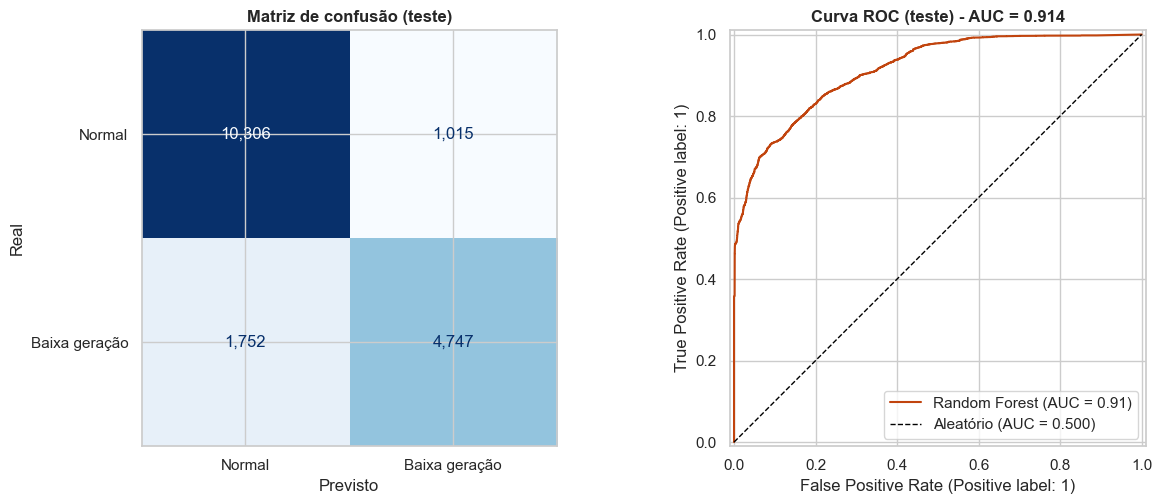

Verdadeiros positivos (evento previsto e ocorrido): 4.747
Falsos negativos (evento NÃO previsto e ocorrido) : 1.752   <- custo operacional alto
Falsos positivos (alarme sem evento)              : 1.015   <- custo de reserva ociosa

Recall do evento: 73.0%  |  Precisão do evento: 82.4%


In [13]:
fig, ax = plt.subplots(1, 2, figsize=(13, 5.2))

cm = confusion_matrix(yc_te, pred_clf)
ConfusionMatrixDisplay(cm, display_labels=['Normal', 'Baixa geração']).plot(
    ax=ax[0], cmap='Blues', colorbar=False, values_format=',d')
ax[0].set_title('Matriz de confusão (teste)')
ax[0].set_xlabel('Previsto'); ax[0].set_ylabel('Real')

RocCurveDisplay.from_predictions(yc_te, proba_te, ax=ax[1], color='#c1440e',
                                 name=f'{melhor_clf_nome.split(" - ")[1]}')
ax[1].plot([0, 1], [0, 1], 'k--', lw=1, label='Aleatório (AUC = 0.500)')
ax[1].set_title(f'Curva ROC (teste) - AUC = {auc:.3f}')
ax[1].legend(loc='lower right')

plt.tight_layout(); plt.show()

vn, fp, fn, vp = cm.ravel()
print(f"Verdadeiros positivos (evento previsto e ocorrido): {vp:,}".replace(',', '.'))
print(f"Falsos negativos (evento NÃO previsto e ocorrido) : {fn:,}   <- custo operacional alto".replace(',', '.'))
print(f"Falsos positivos (alarme sem evento)              : {fp:,}   <- custo de reserva ociosa".replace(',', '.'))
print(f"\nRecall do evento: {vp / (vp + fn):.1%}  |  Precisão do evento: {vp / (vp + fp):.1%}")


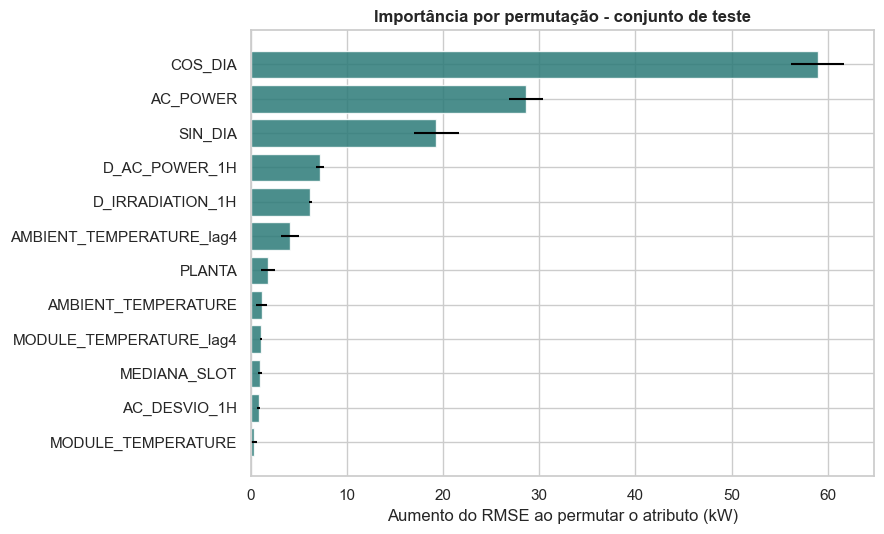

,atributo,importância,std
0,COS_DIA,58.950,2.769
1,AC_POWER,28.622,1.791
2,SIN_DIA,19.319,2.312
3,D_AC_POWER_1H,7.216,0.381
4,D_IRRADIATION_1H,6.204,0.166
5,AMBIENT_TEMPERATURE_lag4,4.063,0.933
6,PLANTA,1.829,0.746
7,AMBIENT_TEMPERATURE,1.160,0.549
8,MODULE_TEMPERATURE_lag4,1.090,0.095
9,MEDIANA_SLOT,0.990,0.188


In [14]:
# Importância por permutação: qual atributo, se embaralhado, degrada o RMSE
sub = np.random.default_rng(RANDOM_STATE).choice(len(X_te), min(4000, len(X_te)), replace=False)
imp = permutation_importance(modelo_final, X_te.iloc[sub], y_te.iloc[sub],
                             n_repeats=5, random_state=RANDOM_STATE,
                             scoring='neg_root_mean_squared_error', n_jobs=-1)

tab_imp = (pd.DataFrame({'atributo': ATRIBUTOS,
                         'importância': imp.importances_mean,
                         'std': imp.importances_std})
           .sort_values('importância', ascending=False).head(12).reset_index(drop=True))

plt.figure(figsize=(9, 5.5))
plt.barh(tab_imp['atributo'][::-1], tab_imp['importância'][::-1],
         xerr=tab_imp['std'][::-1], color='#2b7a78', alpha=0.85)
plt.xlabel('Aumento do RMSE ao permutar o atributo (kW)')
plt.title('Importância por permutação - conjunto de teste')
plt.tight_layout(); plt.show()
tab_imp.round(3)


---
**3.1 Escolha do modelo final:**

**Trilha A.** O critério (1) elege o E5 (HistGradientBoosting ajustado), com RMSE de CV de **168,9 ± 7,4 kW**, o menor entre os cinco. A vantagem sobre o 2º colocado (E2 Random Forest, 171,3 kW) é de apenas **2,5 kW**, menor que um desvio-padrão entre folds (7,4 kW). Pelo critério (2), os dois são estatisticamente indistinguíveis. O desempate cabe ao critério (3), custo e simplicidade e aqui o E5 leva vantagem decisiva: ajusta em ~4,8 s contra os ~46,8 s do Random Forest (10× mais lento) para o mesmo desempenho. Os hiperparâmetros do E5, encontrados pela busca aleatória, são `learning_rate=0.03`, `max_iter=300`, `max_leaf_nodes=31`, `min_samples_leaf=20`, `l2_regularization=1.0`.

No conjunto de teste (tocado uma única vez), o E5 atinge **RMSE 146,8 kW**, **MAE 73,7 kW** e **R² 0,797**, uma **redução de 22,6%** sobre o piso de persistência (189,6 kW). O MAE equivale a apenas **5,2%** da capacidade máxima observada (1.411 kW). A importância por permutação mostra que os atributos dominantes são a **codificação cíclica da hora** (`COS_DIA`, `SIN_DIA`) e a **potência atual** (`AC_POWER`), coerente com o domínio: a geração é governada pela posição no dia e pela inércia de curto prazo. As rampas (`D_AC_POWER_1H`, `D_IRRADIATION_1H`) aparecem em seguida, confirmando seu papel nas transições.

**Trilha B.** O modelo final é o C2 (Random Forest), com ROC-AUC de CV de **0,939 ± 0,013**, o melhor entre os três, embora muito próximo do C1 Logística (0,932) e do C3 (0,930). No teste, atinge **ROC-AUC 0,914** contra o piso de 0,547, um salto grande e inequívoco. O `classification_report` mostra F1 de **0,774** na classe de evento, com recall de 73,0% e precisão de 82,4%.

**Leitura conjunta.** A regressão do valor exato melhora modestamente sobre o piso (22,6%), enquanto a classificação do evento de déficit salta de 0,547 para 0,914 de AUC. Prever *quantos* kW é difícil; prever *se haverá déficit* é fácil, e é esta a decisão operacional relevante.

---
**4. Análise de erros:**

Um RMSE agregado esconde a estrutura do erro. Aqui o erro é decomposto pelas dimensões que têm significado físico e operacional: **hora do dia**, **nível de irradiância**, **rampas de nebulosidade**, **planta** e **inversor**.

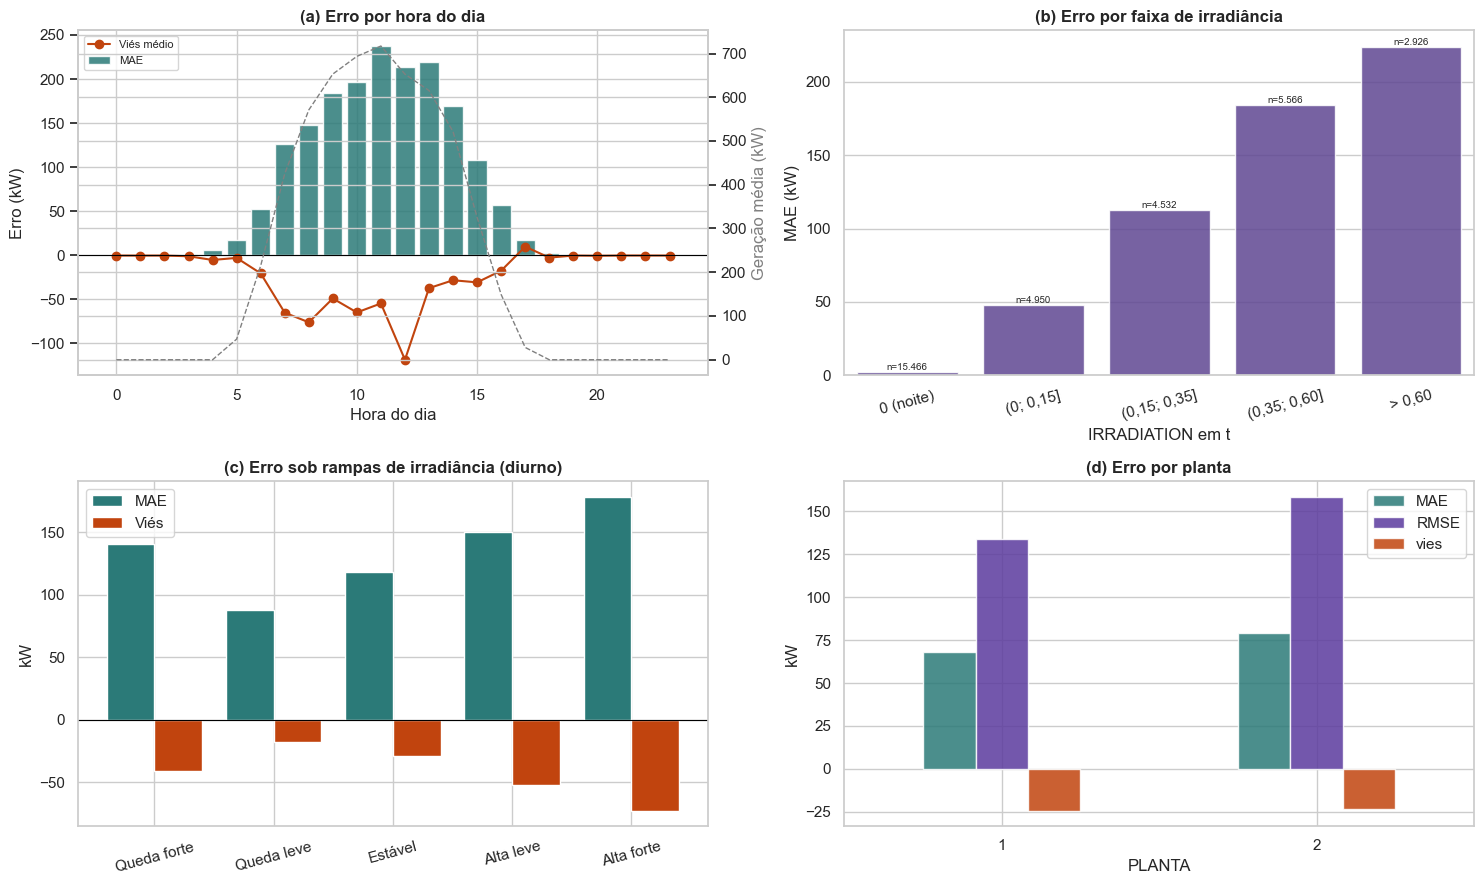

,HORA,mae,vies,geracao
0,0,0.42,-0.42,0.00
1,1,0.46,-0.46,0.00
2,2,0.43,-0.43,0.00
3,3,1.20,-1.20,0.00
4,4,5.43,-5.43,0.00
5,5,17.67,-3.09,47.06
6,6,52.74,-20.63,214.76
7,7,126.55,-65.24,424.95
8,8,147.27,-76.20,570.85
9,9,183.97,-49.14,653.03


,PLANTA,MAE,RMSE,vies
0,1,68.203,133.923,-24.327
1,2,79.227,158.508,-23.362


In [15]:
erro = teste[['DATE_TIME', 'PLANTA', 'SOURCE_KEY', 'HORA', 'IRRADIATION',
              'D_IRRADIATION_1H', 'MEDIANA_SLOT', 'DIURNO']].copy()
erro['real'] = y_te.values
erro['previsto'] = pred_te
erro['residuo'] = erro['real'] - erro['previsto']
erro['erro_abs'] = erro['residuo'].abs()

fig, ax = plt.subplots(2, 2, figsize=(15, 9))

# (a) erro por hora do dia
por_hora = erro.groupby('HORA').agg(mae=('erro_abs', 'mean'),
                                    vies=('residuo', 'mean'),
                                    geracao=('real', 'mean')).reset_index()
ax[0, 0].bar(por_hora['HORA'], por_hora['mae'], color='#2b7a78', alpha=0.85, label='MAE')
ax[0, 0].plot(por_hora['HORA'], por_hora['vies'], 'o-', color='#c1440e', lw=1.5, label='Viés médio')
ax2 = ax[0, 0].twinx()
ax2.plot(por_hora['HORA'], por_hora['geracao'], '--', color='gray', lw=1, label='Geração média')
ax2.set_ylabel('Geração média (kW)', color='gray')
ax[0, 0].axhline(0, color='k', lw=0.8)
ax[0, 0].set_xlabel('Hora do dia'); ax[0, 0].set_ylabel('Erro (kW)')
ax[0, 0].set_title('(a) Erro por hora do dia'); ax[0, 0].legend(loc='upper left', fontsize=8)

# (b) erro por faixa de irradiância
faixas = [-0.01, 0.001, 0.15, 0.35, 0.6, 1.5]
rot = ['0 (noite)', '(0; 0,15]', '(0,15; 0,35]', '(0,35; 0,60]', '> 0,60']
erro['faixa_irr'] = pd.cut(erro['IRRADIATION'], bins=faixas, labels=rot)
por_irr = erro.groupby('faixa_irr', observed=True).agg(mae=('erro_abs', 'mean'),
                                                       n=('erro_abs', 'size')).reset_index()
sns.barplot(data=por_irr, x='faixa_irr', y='mae', ax=ax[0, 1], color='#5b3a9e', alpha=0.85)
for i, l in por_irr.iterrows():
    ax[0, 1].text(i, l['mae'], f"n={int(l['n']):,}".replace(',', '.'), ha='center', va='bottom', fontsize=7)
ax[0, 1].set_xlabel('IRRADIATION em t'); ax[0, 1].set_ylabel('MAE (kW)')
ax[0, 1].set_title('(b) Erro por faixa de irradiância'); ax[0, 1].tick_params(axis='x', rotation=15)

# (c) erro sob rampas de irradiância (variação na última hora)
erro['rampa'] = pd.cut(erro['D_IRRADIATION_1H'],
                       bins=[-2, -0.15, -0.03, 0.03, 0.15, 2],
                       labels=['Queda forte', 'Queda leve', 'Estável', 'Alta leve', 'Alta forte'])
por_rampa = erro[erro['DIURNO']].groupby('rampa', observed=True).agg(
    mae=('erro_abs', 'mean'), vies=('residuo', 'mean')).reset_index()
x = np.arange(len(por_rampa))
ax[1, 0].bar(x - 0.2, por_rampa['mae'], 0.4, label='MAE', color='#2b7a78')
ax[1, 0].bar(x + 0.2, por_rampa['vies'], 0.4, label='Viés', color='#c1440e')
ax[1, 0].axhline(0, color='k', lw=0.8)
ax[1, 0].set_xticks(x); ax[1, 0].set_xticklabels(por_rampa['rampa'], rotation=15)
ax[1, 0].set_ylabel('kW'); ax[1, 0].set_title('(c) Erro sob rampas de irradiância (diurno)'); ax[1, 0].legend()

# (d) erro por planta
por_planta = erro.groupby('PLANTA').agg(MAE=('erro_abs', 'mean'),
                                        RMSE=('residuo', lambda s: float(np.sqrt((s ** 2).mean()))),
                                        vies=('residuo', 'mean')).reset_index()
por_planta.plot(x='PLANTA', y=['MAE', 'RMSE', 'vies'], kind='bar', ax=ax[1, 1],
                color=['#2b7a78', '#5b3a9e', '#c1440e'], alpha=0.85)
ax[1, 1].set_ylabel('kW'); ax[1, 1].set_title('(d) Erro por planta'); ax[1, 1].tick_params(axis='x', rotation=0)

plt.tight_layout(); plt.show()
display(por_hora.round(2)); display(por_planta.round(3))


In [16]:
# Concentração do erro: que fração do erro quadrático total vem de que fração das observações?
e2 = np.sort(erro['residuo'].values ** 2)[::-1]
frac = np.cumsum(e2) / e2.sum()
for p in [0.01, 0.05, 0.10, 0.25]:
    k = int(p * len(e2))
    print(f"  {p:4.0%} das observações com maior erro concentram {frac[k - 1]:5.1%} do erro quadrático total")

print(f"\nErro em período noturno (MEDIANA_SLOT = 0): MAE = {erro[~erro['DIURNO']]['erro_abs'].mean():.3f} kW"
      f"  ({(~erro['DIURNO']).mean():.1%} das linhas)")
print(f"Erro em período diurno                    : MAE = {erro[erro['DIURNO']]['erro_abs'].mean():.3f} kW")

# Piores inversores: erro sistemático localizado?
piores = (erro[erro['DIURNO']].groupby(['PLANTA', 'SOURCE_KEY'])
          .agg(MAE=('erro_abs', 'mean'), vies=('residuo', 'mean'), n=('erro_abs', 'size'))
          .sort_values('MAE', ascending=False).head(8).reset_index())
print("\nInversores com maior MAE diurno (viés negativo = modelo superestima o inversor):")
display(piores.round(3))


    1% das observações com maior erro concentram 24.8% do erro quadrático total
    5% das observações com maior erro concentram 60.3% do erro quadrático total
   10% das observações com maior erro concentram 78.3% do erro quadrático total
   25% das observações com maior erro concentram 97.1% do erro quadrático total

Erro em período noturno (MEDIANA_SLOT = 0): MAE = 2.467 kW  (46.7% das linhas)
Erro em período diurno                    : MAE = 136.222 kW

Inversores com maior MAE diurno (viés negativo = modelo superestima o inversor):


,PLANTA,SOURCE_KEY,MAE,vies,n
0,2,4UPUqMRk7TRMgml,159.462,-50.523,408
1,2,Qf4GUc1pJu5T6c6,159.348,-60.841,408
2,2,Et9kgGMDl729KT4,152.960,-78.011,408
3,2,mqwcsP2rE7J0TFp,152.430,-33.312,408
4,2,NgDl19wMapZy17u,151.556,-38.233,408
5,2,Quc1TzYxW2pYoWX,151.092,-86.071,408
6,2,Mx2yZCDsyf6DPfv,150.465,-55.657,408
7,2,oZ35aAeoifZaQzV,150.181,-53.307,408


,n,hora_media,irradiancia_media,rampa_media,proba_media
tipo,,,,,
FN,1752,12.677,0.432,-0.046,0.282
FP,1015,12.574,0.376,-0.066,0.685
VN,10306,9.853,0.404,0.063,0.128
VP,4747,15.997,0.195,-0.096,0.906


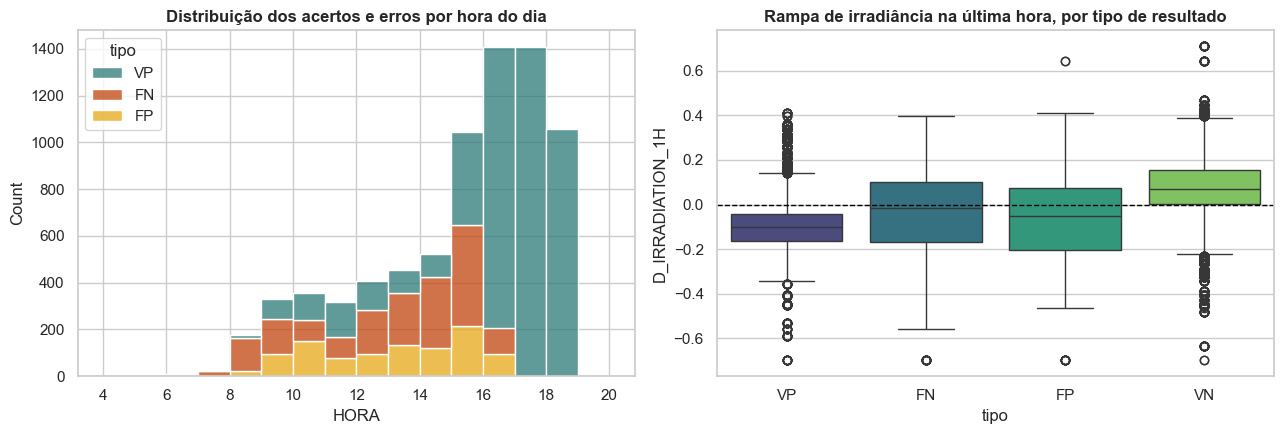

In [17]:
# Onde a Trilha B erra: caracterização dos falsos negativos (evento não previsto)
diag = te_d[['DATE_TIME', 'PLANTA', 'HORA', 'IRRADIATION', 'D_IRRADIATION_1H', 'MEDIANA_SLOT']].copy()
diag['real'] = yc_te.values
diag['prev'] = pred_clf
diag['proba'] = proba_te
diag['tipo'] = np.select(
    [(diag.real == 1) & (diag.prev == 1), (diag.real == 1) & (diag.prev == 0),
     (diag.real == 0) & (diag.prev == 1)],
    ['VP', 'FN', 'FP'], default='VN')

resumo_tipo = diag.groupby('tipo').agg(
    n=('real', 'size'), hora_media=('HORA', 'mean'),
    irradiancia_media=('IRRADIATION', 'mean'),
    rampa_media=('D_IRRADIATION_1H', 'mean'),
    proba_media=('proba', 'mean')).round(3)
display(resumo_tipo)

fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
sns.histplot(data=diag, x='HORA', hue='tipo', hue_order=['VP', 'FN', 'FP'],
             multiple='stack', bins=range(4, 21), ax=ax[0],
             palette=['#2b7a78', '#c1440e', '#e6a817'])
ax[0].set_title('Distribuição dos acertos e erros por hora do dia')

sns.boxplot(data=diag[diag.tipo.isin(['VP', 'FN', 'FP', 'VN'])], x='tipo', y='D_IRRADIATION_1H',
            order=['VP', 'FN', 'FP', 'VN'], ax=ax[1], palette='viridis')
ax[1].axhline(0, color='k', ls='--', lw=1)
ax[1].set_title('Rampa de irradiância na última hora, por tipo de resultado')
plt.tight_layout(); plt.show()


---
**4.1 Interpretação da análise de erros:**

**Onde erra mais.** O erro é fortemente concentrado: 1% das observações com maior erro respondem por **24,8%** do erro quadrático total; 5% respondem por **60,3%** e 10% por **78,3%**. Praticamente todo o erro absoluto é diurno, **MAE de 2,5 kW à noite** contra **136,2 kW de dia**, com as 46,7% de linhas noturnas (geração zero) acertadas trivialmente. Consequência metodológica: o RMSE sobre a base completa **superestima** o modelo; a métrica honesta é a diurna. É por isso que a redução sobre o piso diurno é bem maior que sobre o completo, o ganho do modelo se concentra exatamente onde o problema é difícil.

**Padrão dos erros.** Por hora do dia, o MAE acompanha a curva de geração, com pico ao meio-dia (~237 kW às 11h), esperado porque o erro absoluto escala com a magnitude do sinal. O viés é sistematicamente negativo no período diurno (ex.: −118,7 kW às 12h), ou seja, o modelo tende a superestimar a geração, coerente com um modelo que aprende o comportamento médio e não antecipa bem as quedas por nebulosidade. O gráfico de resíduo vs. previsto exibe heterocedasticidade, pois a dispersão cresce com o nível previsto.

**Significado no domínio.**
1. **Erro por inversor** Os oito inversores com maior MAE diurno estão **todos na Planta 2** (MAE ~150–159 kW), todos com **viés negativo** (−33 a −86 kW). Como `SOURCE_KEY` foi deliberadamente excluído dos atributos, esse resíduo sistemático não vem do modelo "conhecer" a unidade, ele indica que esses inversores específicos **geram menos que o esperado** para o comportamento médio da planta, possível sinal de degradação de hardware (sujeira sobre os módulos, string desconectada, derating térmico). Previa-se uma análise relativa a essa questão para o projeto (conforme entrega do Módulo 1), o qual denominamos detecção de anomalia.
2. **Assimetria de custo na Trilha B.** No teste, o classificador produziu **1.752 falsos negativos** contra **1.015 falsos positivos**. Cada FN é um déficit não antecipado (reserva não despachada), cada FP é reserva ociosa (custo de oportunidade). A caracterização dos FN mostra que ocorrem sob irradiância média mais alta (0,43) e rampa ligeiramente negativa, o modelo perde justamente os eventos de **início de nebulosidade**, em que o estado presente ainda não sinaliza a queda. Como os custos são assimétricos, **o limiar de 0,5 não é o ótimo operacional**: ele deve ser deslocado para baixo, aceitando mais FP para capturar mais eventos. A curva ROC (AUC 0,914) mostra que essa troca é possível sem reajustar o modelo.
3. **Erro entre plantas.** A Planta 2 tem MAE maior (79,2 vs 68,2 kW) e RMSE maior (158,5 vs 133,9 kW) que a Planta 1, reforçando a hipótese do sensor meteorológico e/ou da concentração de inversores subgerando nessa planta.

---
**5. Limitações:**

Cada item é uma condição de treino seguida do que ela limita.

**5.1 34 dias, uma única estação** (pré-monção e entrada da monção, sul da Índia). Limita qualquer afirmação sobre desempenho anual: o RMSE de teste vale para a segunda quinzena de junho de 2020 nas duas usinas, não para "previsão fotovoltaica" em geral. Não há validação em outro ano nem estimativa de deriva sazonal.

**5.2 Split temporal único, teste de 7 dias.** A seleção de hiperparâmetros usou CV temporal e o teste foi tocado uma vez, correto, mas com uma única partição de 7 dias. O intervalo de confiança da métrica de teste é desconhecido; sete dias podem ter sido atipicamente limpos ou nublados.

**5.3 Clima *observado*, não *previsto*.** Os atributos climáticos são medidos em `t` e o alvo está em `t+1h`. Em produção às 10h, isso entrega a geração das 11h, o que o modelo faz. Mas **não** entrega previsão a `t+6h`, pois exigiria previsão numérica de tempo (NWP) como entrada, ausente neste conjunto. O horizonte útil está travado em ~1h; estender ao despacho intradiário (4–6h) exigiria acoplar NWP e revalidar tudo, com a incerteza da entrada climática passando a dominar. É o limite mais sério para uso operacional.

**5.4 Um único sensor meteorológico por planta**, atribuído aos 22 inversores. Sombreamento parcial, passagem de nuvem sobre um setor e sujeira localizada são invisíveis para o atributo, o modelo não distingue "nuvem sobre o inversor X" de "inversor X degradado". É por isso que a análise de resíduo por inversor é sugestiva, não conclusiva, quanto a anomalia de hardware.

**5.5 Inversores tratados como intercambiáveis.** `SOURCE_KEY` foi excluído dos atributos para não confundir identidade com condição e para permitir generalização a uma unidade nova. Em troca, o modelo não captura heterogeneidade real entre unidades, e o erro por inversor de §4 mistura essa heterogeneidade com erro genuíno de previsão.

**5.6 Escalas heterogêneas de `DC_POWER`.** A razão DC/AC de ~10 na Planta 1 contra ~1 na Planta 2 reflete arranjos distintos de string, não maior eficiência. A normalização pelo máximo de treino de cada planta é correção de escala, não reconciliação física: as importâncias de `DC_POWER_NORM` não têm interpretação física direta entre plantas, e uma terceira planta com outra convenção exigiria reajuste.

**5.7 Definição do evento (limiar de 50%)** é escolha do analista, não requisito operacional. Um limiar de 30% ou 70% mudaria a prevalência e todas as métricas da matriz de confusão. O ROC-AUC é robusto ao limiar de *decisão*, mas não ao de *definição do rótulo*; antes de operacionalizar, o limiar deve derivar do custo real de despacho de reserva.

**5.8 Imputação por interpolação linear** dos climáticos ausentes suaviza artificialmente a irradiância exatamente no regime de nebulosidade intermitente, que é onde o modelo mais erra. O volume imputado é pequeno, mas concentrado onde importa. `DAILY_YIELD` e `TOTAL_YIELD` foram descartados por serem acumuladores; a energia acumulada no dia, que teria valor preditivo, foi perdida junto.

**5.9 Ausência de covariáveis de manutenção** (limpeza de módulos, curtailment, indisponibilidade programada). Parte do resíduo atribuído a "erro do modelo" pode ser evento operacional determinístico, conhecido a priori pelo operador. O teto de desempenho alcançável com estes dados é, portanto, menor que o teto físico do problema.

**5.10 Não negatividade imposta a posteriori** por `np.clip(pred, 0, None)`. É correção honesta, mas indica que o modelo não incorpora a restrição física na função de perda. Alternativas, como modelar `log1p(AC_POWER)`, usar perda Poisson/Tweedie, ou um modelo em dois estágios (classificar geração > 0, depois regredir), não foram testadas.

---
---
